In [1]:
!pip install -q --upgrade transformers==4.56.2 diffusers==0.32.2
!pip install torch-directml


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.21.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   ----------------------------------- ---- 7.9/9.0 MB 40.7 MB/s eta 0:00:01
   ---------------------------------------- 9.0/9.0 MB 37.2 MB/s  0:00:00
   ---------------------------------------- 0.0/199.4 MB ? eta -:--:--
   - -------------------------------------- 7.1/199.4 MB 33.6 MB/s eta 0:00:06
   -- ------------------------------------- 14.9/199.4 MB 36.2 MB/s eta 0:00:06
   ---- ----------------------------------- 22.8/199.4 MB 36.1 MB/s eta 0:00:05
   ------ --------------------------------- 32.0/199.4 MB 38.3 MB/s eta 0:00:05
   -------- ------------------------------- 41.2/199.4 MB 39.1 MB/s eta 0:00:05
   ---------- ----------------------------- 50.1/199.4 MB 39.4 MB/s eta 0:00:04
   ----------- ---------------------------- 58.5/199.4 MB 39.6 MB/s eta 0:00:04
   ------------- -------------------------- 66.8/199.4 MB 39.5 MB/s eta 0:00:04
   --------------- ------------------------ 76.0/199.4 MB 40.1 MB/s et

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.6.0+cu124 requires torch==2.6.0+cu124, but you have torch 2.4.1 which is incompatible.


In [ ]:
# GPU 체크


In [2]:
# 허깅 페이스 로그인

import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv(override=True)
hf_token = os.getenv('HF_TOKEN')

if hf_token:
    print(f"존재")
else:
    print("미존재")

login(hf_token, add_to_git_credential=True)

존재


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

d:\anaconda3\envs\llm_new\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\airtr\.cache\huggingface\hub\models--stabilityai--sdxl-turbo. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/4 [00:00<?, ?it/s]

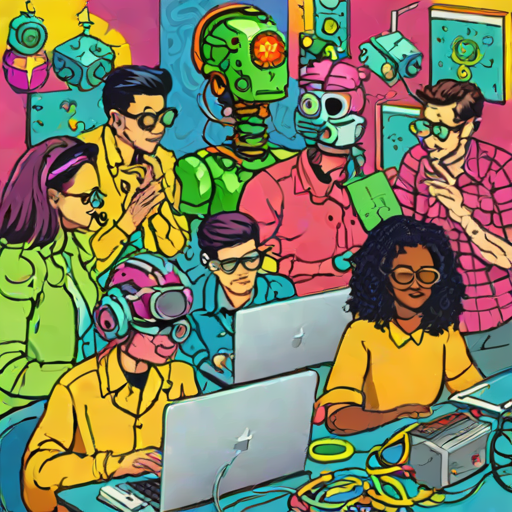

In [3]:
# 엔비디아 GPU가 있어야 사용됨

from IPython.display import display
import torch_directml
from diffusers import AutoPipelineForText2Image

import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
#pipe.to("cuda")  # 엔비디아만 지원

# 윈도우에서 AMD 사용
device = torch_directml.device()
pipe.to(device)

prompt = "AI 엔지니어링을 배우는 학생들의 한 반을 생동감 넘치는 팝어트 스타일로"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

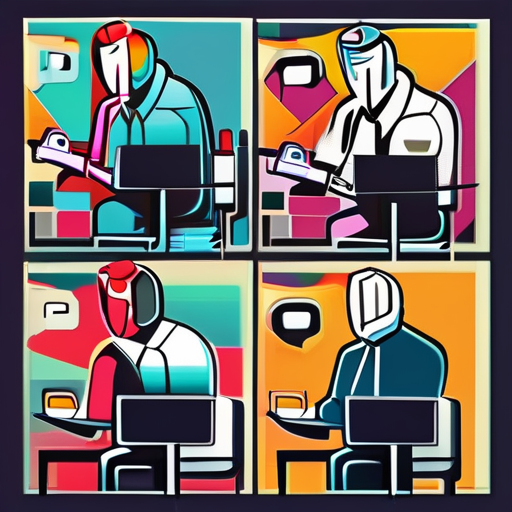

In [2]:
# 다른 모델

from IPython.display import display
from diffusers import DiffusionPipeline
import torch_directml
import torch

pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, use_safetensors=True, variant="fp16")
#pipe.to("cuda")
# 윈도우에서 AMD 사용
device = torch_directml.device()
pipe.to(device)
pipe.enable_attention_slicing()  # 메모리 사용량 줄이기

#prompt = "AI 엔지니어링을 배우는 학생들의 한 반을 생동감 넘치는 팝아트 스타일로"
prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

image = pipe(
            prompt=prompt, 
             num_inference_steps=30,
             height=512, 
             width=512
        ).images[0]

display(image)

In [ ]:
# 한번 더 감싸서 보정하기
# Base 모델: 노이즈에서 시작해서 이미지의 전체적인 구도, 형태, 색감을 빠르게 잡아나갑니다.
# Refiner 모델: base가 만든 결과물을 이어받아서, 디테일(질감, 미세한 표면, 손가락 같은 세부 요소 등)을 다듬어 완성도를 높입니다.

from diffusers import DiffusionPipeline
import torch

base = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True)
base.to("cuda")
refiner = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-refiner-1.0", text_encoder_2=base.text_encoder_2, vae=base.vae, torch_dtype=torch.float16, use_safetensors=True, variant="fp16",)
refiner.to("cuda")

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

# run both experts
image = base(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
).images

image = refiner(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image,
).images[0]

display(image)

In [ ]:
# 부하가 심한 모델

import torch
from diffusers import FluxPipeline
from IPython.display import display
from datetime import datetime

start = datetime.now()

pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", torch_dtype=torch.bfloat16).to("cuda")
generator = torch.Generator(device="cuda").manual_seed(0)
prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

# Generate the image using the GPU
image = pipe(
    prompt,
    guidance_scale=0.0,
    num_inference_steps=4,
    max_sequence_length=256,
    generator=generator
).images[0]

display(image)

stop = datetime.now()
